# Lab 2: Predicting Price and Quantities

## Why Prediction Matters for Causal Inference

Before estimating causal effects, we need to assess how well we can predict the outcome and treatment from the available controls. Under the structural equation model, the quantity and price signals are generated by
$$Q_{it} = a_t(S_{it}, \epsilon_{it})\,P_{it} + q_t(S_{it}, \epsilon_{it}), \qquad P_{it} = p_t(S_{it}, \epsilon^p_{it}),$$
where $S_{it} := (X_{it})$ is the state vector containing product characteristics $X_{it}$.

In the double machine learning (DML) framework, the quality of the causal estimate depends directly on how well the nuisance functions
$$\gamma^Q_t(S_{it}) = E[Q_{it} \mid S_{it}], \qquad \gamma^P_t(S_{it}) = E[P_{it} \mid S_{it}]$$
are estimated. These predictions feed into the partially linear regression (PLR) model
$$Q_{it}^\perp = \delta_t\,P_{it}^\perp + e_{it},$$
where $Q_{it}^\perp = Q_{it} - E[Q_{it} \mid S_{it}]$ and $P_{it}^\perp = P_{it} - E[P_{it} \mid S_{it}]$ are residuals. Better nuisance estimation means tighter residuals and more precise estimation of the causal parameter $\delta_t$.

We considers three types of control function specifications:
- **Linear**: $\gamma_t(S_{it}) = g_t^T S_{it}$
- **Interactive linear**: $\gamma_t(S_{it}) = d_t^T I(S_{it})$, including interactions of lagged variables with embedding features
- **Nonlinear**: $\gamma_t(S_{it})$ approximated nonparametrically by boosted trees

## Setup

We compare three feature specifications:

1. Lagged variables and tabular controls only
2. The above, plus five PCA components of the embedding vectors
3. The above (without PCA), plus five cosine similarity scores to cluster centroids

For each specification we fit an OLS regression (linear) and a gradient boosted tree model (LightGBM, nonlinear) and report the out-of-sample $R^2$ on the test set.

In [1]:
import re
import datasets
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import pairwise_distances, r2_score

palette = sns.color_palette("colorblind")

## 1. Load Data

In [2]:
ds = datasets.load_dataset("janteichertkluge/demand-analysis-repro")
df_train = ds["train"].to_pandas()
df_test  = ds["test"].to_pandas()

print(f"Train: {df_train.shape}  |  Test: {df_test.shape}")

Train: (38146, 75)  |  Test: (38041, 75)


## 2. Construct Embedding Features

We center and normalize the embeddings using training-set statistics, then compute PCA projections and cluster similarity scores. All transformations are fitted on the training set and applied to both sets.

In [3]:
emb_cols = sorted([c for c in df_train.columns if c.startswith("emb_")])
print(f"Embedding dimensions: {len(emb_cols)}")

emb_tr = df_train[emb_cols].values.astype(float)
emb_te = df_test[emb_cols].values.astype(float)

global_mean = emb_tr.mean(axis=0)
emb_tr_n = normalize(emb_tr - global_mean, axis=1)
emb_te_n = normalize(emb_te - global_mean, axis=1)

# PCA: fit on training set, transform both
pca = PCA(n_components=5, random_state=42)
pca.fit(emb_tr_n)
pca_cols = [f"pca_{i}" for i in range(5)]
df_train[pca_cols] = pca.transform(emb_tr_n)
df_test[pca_cols]  = pca.transform(emb_te_n)

# K-means: fit on training set, compute similarities for both
km = KMeans(n_clusters=5, random_state=42, n_init=50)
km.fit(emb_tr_n)
sim_cols = [f"sim_cluster_{i}" for i in range(5)]
for j, centroid in enumerate(km.cluster_centers_):
    df_train[sim_cols[j]] = 1.0 - pairwise_distances(
        emb_tr_n, centroid.reshape(1, -1), metric="cosine").ravel()
    df_test[sim_cols[j]]  = 1.0 - pairwise_distances(
        emb_te_n, centroid.reshape(1, -1), metric="cosine").ravel()

print("PCA and similarity features constructed.")

Embedding dimensions: 5
PCA and similarity features constructed.


## 3. Construct Dummies

 We add subcategory and time fixed effects as dummy variables.

In [4]:
# Subcategory dummies (drop one category to avoid perfect collinearity)
if "subcat_aggregated" in df_train.columns:
    sub_tr = pd.get_dummies(df_train["subcat_aggregated"], prefix="sub", drop_first=True).astype(int)
    sub_te = pd.get_dummies(df_test["subcat_aggregated"],  prefix="sub", drop_first=True).astype(int)
    sub_te = sub_te.reindex(columns=sub_tr.columns, fill_value=0)
    df_train[sub_tr.columns] = sub_tr.values
    df_test[sub_te.columns]  = sub_te.values
    subcat_cols = sub_tr.columns.tolist()
else:
    subcat_cols = []

# Time dummies (drop one period)
time_tr = pd.get_dummies(df_train["date"], prefix="t", drop_first=True).astype(int)
time_te = pd.get_dummies(df_test["date"],  prefix="t", drop_first=True).astype(int)
time_te = time_te.reindex(columns=time_tr.columns, fill_value=0)
df_train[time_tr.columns] = time_tr.values
df_test[time_te.columns]  = time_te.values
time_cols = time_tr.columns.tolist()


print(f"With dummies: Train: {df_train.shape}  |  Test: {df_test.shape}")

With dummies: Train: (38146, 107)  |  Test: (38041, 107)


## 4. Define Feature Specifications

### Connection to the Causal Model

The three feature specifications below correspond to different enrichments of the state vector $S_{it} = (Q_{i,t-1}, P_{i,t-1}, X_{it})$. The **Tabular** specification uses only structured controls $X^o_{it}$ (subcategory, time dummies, marketplace variables). Adding **PCA** includes $X^{pc}_i = (\gamma_k^T X^e_i)_{k=1}^5$; adding **Sim** includes $X^{sim}_i = (c_k^T X^e_i)_{k=1}^5$. The richer the state, the more confounding the nuisance models $\gamma^Q_t(S_{it})$ and $\gamma^P_t(S_{it})$ can absorb, leading to less biased residuals for the second-stage causal regression in Lab 3.

In [5]:
outcome   = "Q_t"
treatment = "P_bb_t"

tabular_candidates = [
    "RATING_lag1", "REVIEW_COUNT_lag1",
    "New Offer Count: Current",
    "Count of retrieved live offers: New, FBA",
    "Count of retrieved live offers: New, FBM",
    "Lightning Deals: Upcoming Deal",
    "Buy Box: Is FBA",
]
tabular_controls = [c for c in tabular_candidates if c in df_train.columns]
base_controls    = tabular_controls + subcat_cols + time_cols

feature_specs = {
    "Tabular":           base_controls,
    "Tabular + PCA":     base_controls + pca_cols,
    "Tabular + Sim":     base_controls + sim_cols,
}

print(f"Base controls: {len(base_controls)} variables")
print(f"PCA controls:  {len(pca_cols)} additional variables")
print(f"Sim controls:  {len(sim_cols)} additional variables")

Base controls: 27 variables
PCA controls:  5 additional variables
Sim controls:  5 additional variables


## 5. Estimate Prediction Models

We fit each model on the training set and evaluate it on the test set. Because observations from the same product are serially correlated, we do not use the training $R^2$ as a measure of fit quality. The test-set $R^2$ is what matters for the downstream causal estimator.

In [6]:
def build_X_ols(df, controls):
    cols = [c for c in controls if c in df.columns]
    X = df[cols].fillna(0).copy()
    X.columns = [re.sub(r"[^A-Za-z0-9_]+", "", c) for c in X.columns]
    return sm.add_constant(X, has_constant="add")

def build_X_lgbm(df, controls):
    cols = [c for c in controls if c in df.columns]
    X = df[cols].fillna(0).copy()
    X.columns = [re.sub(r"[^A-Za-z0-9_]+", "", c) for c in X.columns]
    return X

results = []

for spec_name, controls in feature_specs.items():
    print(f"\n{'='*60}")
    print(f"  {spec_name}")
    print(f"{'='*60}")

    # OLS
    X_tr = build_X_ols(df_train, controls)
    X_te = build_X_ols(df_test,  controls).reindex(columns=X_tr.columns, fill_value=0)

    ols_q = sm.OLS(df_train[outcome],   X_tr).fit()
    ols_p = sm.OLS(df_train[treatment], X_tr).fit()

    r2_q_tr = r2_score(df_train[outcome],   ols_q.predict(X_tr))
    r2_q_te = r2_score(df_test[outcome],    ols_q.predict(X_te))
    r2_p_tr = r2_score(df_train[treatment], ols_p.predict(X_tr))
    r2_p_te = r2_score(df_test[treatment],  ols_p.predict(X_te))
    print(f"  OLS       Q: train {r2_q_tr:.4f}  test {r2_q_te:.4f}    "
          f"P: train {r2_p_tr:.4f}  test {r2_p_te:.4f}")
    results.append({"Specification": spec_name, "Model": "OLS",
                    "R2 Q Train": r2_q_tr, "R2 Q Test": r2_q_te,
                    "R2 P Train": r2_p_tr, "R2 P Test": r2_p_te})

    # LightGBM
    Xl_tr = build_X_lgbm(df_train, controls)
    Xl_te = build_X_lgbm(df_test,  controls).reindex(columns=Xl_tr.columns, fill_value=0)

    lgbm_q = LGBMRegressor(n_estimators=500, learning_rate=0.02, random_state=42, verbose=-1)
    lgbm_q.fit(Xl_tr, df_train[outcome])
    lgbm_p = LGBMRegressor(n_estimators=500, learning_rate=0.02, random_state=42, verbose=-1)
    lgbm_p.fit(Xl_tr, df_train[treatment])

    r2_q_tr = r2_score(df_train[outcome],   lgbm_q.predict(Xl_tr))
    r2_q_te = r2_score(df_test[outcome],    lgbm_q.predict(Xl_te))
    r2_p_tr = r2_score(df_train[treatment], lgbm_p.predict(Xl_tr))
    r2_p_te = r2_score(df_test[treatment],  lgbm_p.predict(Xl_te))
    print(f"  LightGBM  Q: train {r2_q_tr:.4f}  test {r2_q_te:.4f}    "
          f"P: train {r2_p_tr:.4f}  test {r2_p_te:.4f}")
    results.append({"Specification": spec_name, "Model": "LightGBM",
                    "R2 Q Train": r2_q_tr, "R2 Q Test": r2_q_te,
                    "R2 P Train": r2_p_tr, "R2 P Test": r2_p_te})

df_results = pd.DataFrame(results).set_index(["Specification", "Model"])


  Tabular
  OLS       Q: train 0.0794  test 0.0658    P: train 0.1585  test 0.1589
  LightGBM  Q: train 0.2937  test 0.0968    P: train 0.3811  test 0.1829

  Tabular + PCA
  OLS       Q: train 0.7059  test 0.2992    P: train 0.7372  test 0.4531
  LightGBM  Q: train 0.8890  test 0.4186    P: train 0.9715  test 0.5972

  Tabular + Sim
  OLS       Q: train 0.7059  test 0.2992    P: train 0.7372  test 0.4531
  LightGBM  Q: train 0.8028  test 0.3270    P: train 0.9070  test 0.5012


## 6. Results

The table below reports test-set $R^2$ values, expressed as percentages. Notice that embedding features consistently improve fit over the tabular baseline. This is important: better prediction of both $Q_{it}$ and $P_{it}$ from the controls means tighter residuals and more precise causal estimates downstream.

The CACE $\alpha_t(S_{it})$ is identified by the CAPE $\delta_t(S_{it})$, provided the nuisance functions $\gamma^Q_t(S_{it})$ and $\gamma^P_t(S_{it})$ are estimated consistently. The $R^2$ values in the table directly measure how well these nuisance functions are estimated.

In [7]:
display_cols = ["R2 Q Test", "R2 P Test"]
print("Test-set R2 (%)")
(df_results[display_cols] * 100).round(2)

Test-set R2 (%)


R2 Q Test  R2 P Test
Specification Model                         
Tabular       OLS            6.58      15.89
              LightGBM       9.68      18.29
Tabular + PCA OLS           29.92      45.31
              LightGBM      41.86      59.72
Tabular + Sim OLS           29.92      45.31
              LightGBM      32.70      50.12

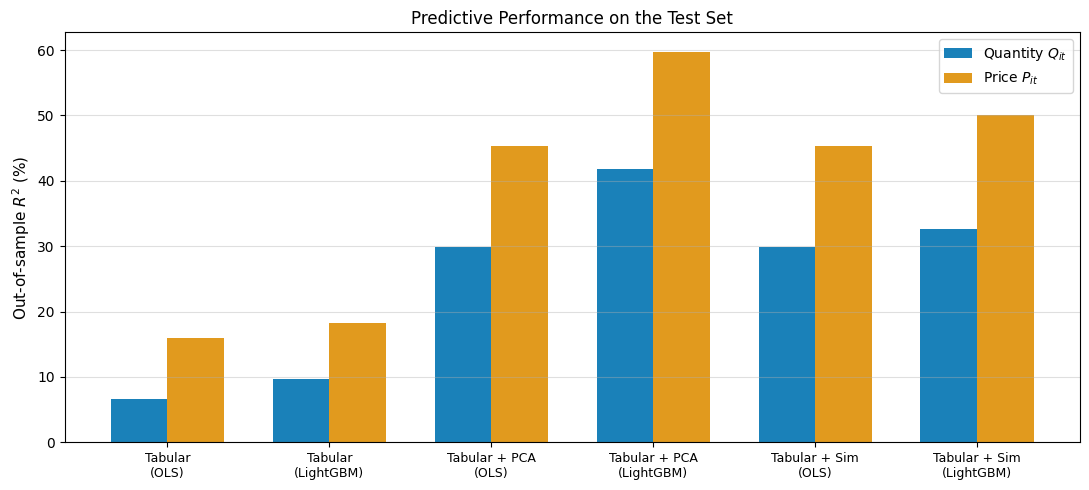

In [8]:
df_plot = df_results.reset_index()
df_plot["label"] = df_plot["Specification"] + "\n(" + df_plot["Model"] + ")"

x = np.arange(len(df_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, df_plot["R2 Q Test"] * 100, w,
       label="Quantity $Q_{it}$",  color=palette[0], alpha=0.9)
ax.bar(x + w/2, df_plot["R2 P Test"] * 100, w,
       label="Price $P_{it}$", color=palette[1], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(df_plot["label"], fontsize=9)
ax.set_ylabel("Out-of-sample $R^2$ (%)", fontsize=11)
ax.set_title("Predictive Performance on the Test Set", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

## Discussion

Several patterns are worth noting.

First, predicting price tends to be harder than predicting quantity. Prices are set by sellers and can change for reasons unrelated to the observable product characteristics in our dataset. This residual price variation is precisely the source of identifying information that DML exploits in Lab 3.

Second, boosted trees consistently outperform OLS. The state space is high-dimensional and the relationship between controls and outcomes is likely nonlinear. Tree-based methods handle both without requiring us to specify the functional form.